# Impact of AI on students
In this project I will explore and analyze the impact of the usage of artificial intelligence on students using a public dataset available on kaggle.

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("ai_student_impact_dataset.csv")
df.head(5)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


The dataset has 16 features related to the students' studies and ai usage. In this project I will focus on predictive modeling, specifically the classification of the burnout risk level.

## Exploratory data analysis

In [2]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

There are no missing values in the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [4]:
numerical_cols = []
string_like_cols = []

for c in list(df.columns):
    if df[c].dtype == 'int64' or df[c].dtype == 'float64':
        numerical_cols.append(c)
    else:
        string_like_cols.append(c)
print("Numerical features:", numerical_cols, "\n")
print("String-like features:", string_like_cols)

Numerical features: ['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score'] 

String-like features: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level']


Let's look at the numerical features first, but drop the student id as it is of no use for predictive analytics.

In [5]:
numerical_cols.remove("Student_ID")
for c in numerical_cols:
    print(df[c].value_counts())

Pre_Semester_GPA
3.433    60
3.392    59
3.419    58
3.221    58
3.435    57
         ..
1.294     1
1.423     1
1.743     1
1.872     1
1.701     1
Name: count, Length: 2389, dtype: int64
Weekly_GenAI_Hours
40.00    448
0.28      81
0.33      77
0.11      73
0.95      72
        ... 
30.78      1
31.53      1
29.81      1
33.64      1
38.96      1
Name: count, Length: 3566, dtype: int64
Tool_Diversity
3    16926
2    11830
1     8141
4     8081
5     5022
Name: count, dtype: int64
Traditional_Study_Hours
1.00     1269
9.47       54
9.88       54
10.99      52
12.76      51
         ... 
25.53       1
24.66       1
24.89       1
28.00       1
27.52       1
Name: count, Length: 2516, dtype: int64
Perceived_AI_Dependency
3     10478
4      9934
2      8874
1      7303
5      6745
6      3521
7      1722
8       855
9       378
10      190
Name: count, dtype: int64
Anxiety_Level_During_Exams
4     8749
5     8222
3     7806
6     6107
2     5752
1     5655
7     3850
8     2088
9     1151

Based on this, we can assess that Tool_Diversity, Perceived_AI_Dependency and Anxiety_Level_During_Exams are categorical features.

In [6]:
categorical_features = ["Tool_Diversity", "Perceived_AI_Dependency", "Anxiety_Level_During_Exams"]
numerical_cols = [x for x in numerical_cols if x not in categorical_features]
numerical_cols

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Traditional_Study_Hours',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

The rest of the numerical features are continuous values. Let's explore their distribution and ranges.

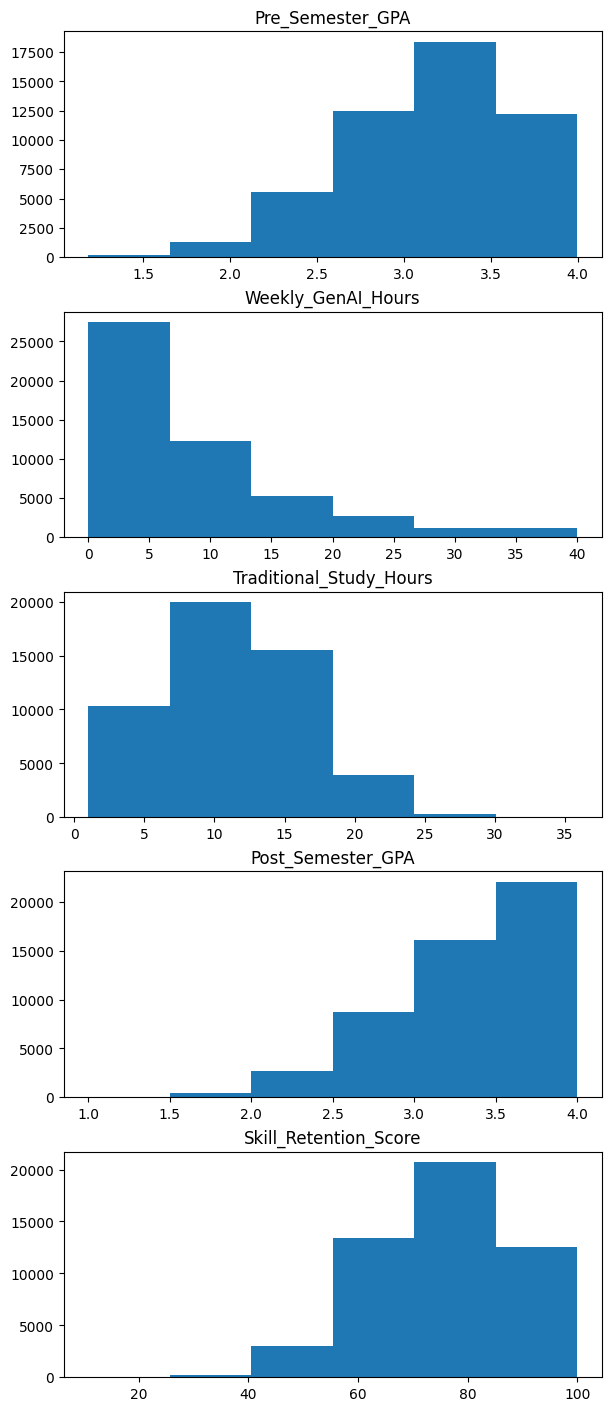

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_distribution_of_numerical(data=df):
    fig,axes = plt.subplots(5, figsize=(6,14), layout="constrained")
    idx = 0

    for c in numerical_cols:
        axes[idx].hist(data[c], bins=6)
        axes[idx].set_title(c)
        idx += 1
plot_distribution_of_numerical()

The ranges are different and the distribution of the data is skewed in all cases. After doing the train-test split, these features will be scaled.
Now I will take a look at the string features.

In [8]:
for c in string_like_cols:
    print(df[c].value_counts())

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64
Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


All of the above are categorical features.

In [9]:
categorical_features = categorical_features + string_like_cols
categorical_features

['Tool_Diversity',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

## Data preparation
Having done the initial data exploration, we can move on to the data preparation phase. The three most important things to do here are: splitting the dataset, scaling the numerical features and encoding the categorical features. 

In [10]:
Y = df["Burnout_Risk_Level"]
X = df.drop(["Burnout_Risk_Level","Student_ID"] , axis=1)

Y.value_counts()

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

The target labels are not balanced, thus stratifying is required when splitting the data.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, stratify=Y, shuffle=True, random_state=42)

In [12]:
X_train.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
17293,Medical,Junior,2.512,21.53,Copywriting/Drafting,Intermediate,3,True,5.54,4,Actively_Encouraged,3,2.761,54.59
25020,STEM,Junior,2.602,18.53,Ideation,Advanced,3,True,8.88,3,Allowed_With_Citation,1,2.983,78.62
22173,STEM,Senior,2.865,14.07,Debugging/Troubleshooting,Beginner,2,True,4.39,7,Allowed_With_Citation,8,2.986,73.33
41032,STEM,Junior,2.582,5.46,Debugging/Troubleshooting,Beginner,3,False,8.16,2,Allowed_With_Citation,4,2.811,58.08
7233,Business,Freshman,2.164,13.82,Ideation,Beginner,3,True,12.90,5,Actively_Encouraged,5,2.339,52.22


In [13]:
y_train.head()

17293      High
25020    Medium
22173    Medium
41032       Low
7233        Low
Name: Burnout_Risk_Level, dtype: object

### Feature Scaling

Since most of the algorithms that will be tested later on require standard normal distribution, I will use sklearn's StandardScaler. However due to the skewness present, first let's use a power transformer.

In [14]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

pt = PowerTransformer()
X_train[numerical_cols] = pt.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = pt.transform(X_test[numerical_cols])

ss = StandardScaler()
X_train[numerical_cols] = ss.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = ss.transform(X_test[numerical_cols])
X_train.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
17293,Medical,Junior,-1.305589,1.417463,Copywriting/Drafting,Intermediate,3,True,-1.095305,4,Actively_Encouraged,3,-1.209651,-1.552158
25020,STEM,Junior,-1.161330,1.247569,Ideation,Advanced,3,True,-0.410616,3,Allowed_With_Citation,1,-0.849553,0.187367
22173,STEM,Senior,-0.695614,0.942155,Debugging/Troubleshooting,Beginner,2,True,-1.344533,7,Allowed_With_Citation,8,-0.844341,-0.215520
41032,STEM,Junior,-1.194036,-0.030973,Debugging/Troubleshooting,Beginner,3,False,-0.554179,2,Allowed_With_Citation,4,-1.132854,-1.314637
7233,Business,Freshman,-1.795732,0.922572,Ideation,Beginner,3,True,0.360643,5,Actively_Encouraged,5,-1.765813,-1.710259


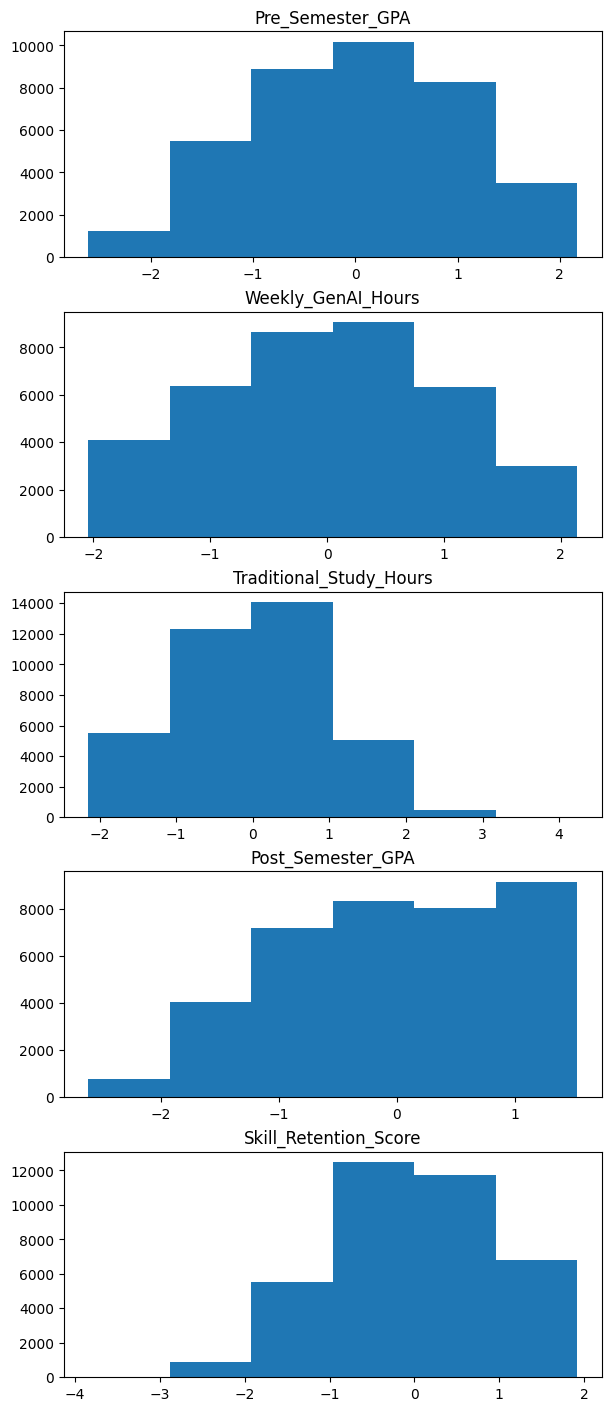

In [15]:
plot_distribution_of_numerical(data=X_train)

The distribution is closer to standard normal.

### Encoding

In [16]:
categorical_features

['Tool_Diversity',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

Tool diversity, perceived ai dependency and anxiety level have been added here from the numerical features. As such there is no need to encode them.

In [17]:
cols_to_encode = categorical_features[3:]
cols_to_encode

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

The year of study and prompt engineer skill have an ordinality to them, which has to be represented in its encoding as well.

In [18]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

cols_to_encode.remove("Year_of_Study")
cols_to_encode.remove("Prompt_Engineering_Skill")
cols_to_encode.remove("Burnout_Risk_Level")

ohe = OneHotEncoder(sparse_output=False)
train_encoded = pd.DataFrame(
    ohe.fit_transform(X_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    ohe.transform(X_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=X_test.index
)

X_train = pd.concat([X_train.drop(columns=cols_to_encode), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cols_to_encode), test_encoded], axis=1)

oe = OrdinalEncoder(categories=[["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]])
X_train["Year_of_Study"] = oe.fit_transform(X_train[["Year_of_Study"]])
X_test["Year_of_Study"] = oe.transform(X_test[["Year_of_Study"]])

oe = OrdinalEncoder(categories=[["Beginner", "Intermediate", "Advanced"]])
X_train["Prompt_Engineering_Skill"] = oe.fit_transform(X_train[["Prompt_Engineering_Skill"]])
X_test["Prompt_Engineering_Skill"] = oe.transform(X_test[["Prompt_Engineering_Skill"]])

oe = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
y_train = pd.DataFrame(oe.fit_transform(y_train.to_frame()))
y_test = pd.DataFrame(oe.transform(y_test.to_frame()))

X_train = X_train.reset_index().drop("index", axis=1)
X_test = X_test.reset_index().drop("index", axis=1)
X_train.head()

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,...,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Paid_Subscription_False,Paid_Subscription_True,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,2.0,-1.305589,1.417463,1.0,3,-1.095305,4,3,-1.209651,-1.552158,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,2.0,-1.161330,1.247569,2.0,3,-0.410616,3,1,-0.849553,0.187367,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,3.0,-0.695614,0.942155,0.0,2,-1.344533,7,8,-0.844341,-0.215520,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2.0,-1.194036,-0.030973,0.0,3,-0.554179,2,4,-1.132854,-1.314637,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,-1.795732,0.922572,0.0,3,0.360643,5,5,-1.765813,-1.710259,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [19]:
y_train.head()

,0
0,2.0
1,1.0
2,1.0
3,0.0
4,0.0


## Model selection

In this section I will compare some classifier models to find the one most suitable for this task. As there are no specific cases for which we want to optimize, the comparison will be based on the F1 score.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import f1_score

In [21]:
base_models = [LogisticRegression(), SVC(), DecisionTreeClassifier(), KNeighborsClassifier(), RandomForestClassifier(), ExtraTreesClassifier()]
best_model = base_models[0]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
best_model_f1 = f1_score(y_test, y_pred, average="weighted")

for model in base_models[1:]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    model_f1 = f1_score(y_test, y_pred, average="weighted")
    if model_f1 >= best_model_f1:
        best_model = model
        best_model_f1 = model_f1

print(f"The best model is {best_model} with an F1 score of {round(best_model_f1, 2)}")

The best model is LogisticRegression() with an F1 score of 0.53


## Hyperparameter tuning
Logistic regression turned out to be the best performing model. In this step I will use grid search to find the best combination of hyperparameters.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid={"penalty": ["l1", "l2", "elasticnet"],
            "C": [0.3, 0.5, 0.8, 1.0],
            "l1_ratio": [0.3, 0.5, 0.8],
            "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]}

grid_search = GridSearchCV(estimator=best_model, param_grid=param_grid, cv=5, error_score=0, scoring="f1_weighted", n_jobs=-1)
grid_search.fit(X_train, y_train)
print("The best parameters are: ", grid_search.best_params_)

The best parameters are:  {'C': 0.5, 'l1_ratio': 0.3, 'penalty': 'l2', 'solver': 'lbfgs'}


In [23]:
model = grid_search.best_estimator_

## Model evaluation

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.55      0.44      0.49      4092
         1.0       0.48      0.61      0.54      5286
         2.0       0.63      0.51      0.56      3122

    accuracy                           0.53     12500
   macro avg       0.55      0.52      0.53     12500
weighted avg       0.54      0.53      0.53     12500



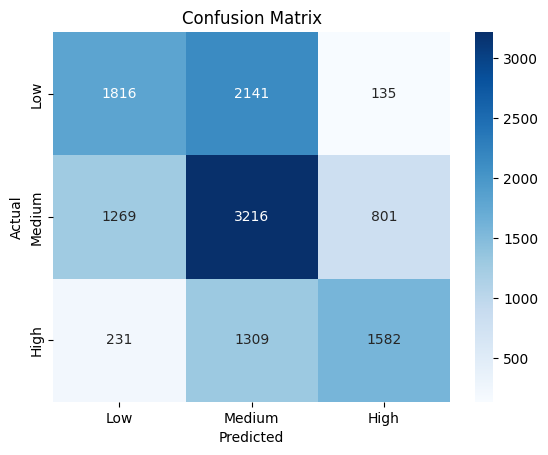

In [26]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Feature importance:


In [27]:
X_train_full = X_train.copy()
X_train_full["target"] = y_train
X_train_full.corr()["target"].sort_values(key=abs, ascending=False)

target                                        1.000000
Weekly_GenAI_Hours                            0.442456
Perceived_AI_Dependency                       0.370968
Anxiety_Level_During_Exams                    0.164473
Year_of_Study                                 0.163966
Traditional_Study_Hours                      -0.132582
Paid_Subscription_False                      -0.099848
Paid_Subscription_True                        0.099848
Pre_Semester_GPA                             -0.094403
Post_Semester_GPA                            -0.091725
Major_Category_STEM                           0.081713
Skill_Retention_Score                        -0.054273
Major_Category_Humanities                    -0.053604
Institutional_Policy_Strict_Ban               0.047265
Primary_Use_Case_Debugging/Troubleshooting    0.029900
Primary_Use_Case_Copywriting/Drafting        -0.026469
Institutional_Policy_Actively_Encouraged     -0.021508
Institutional_Policy_Allowed_With_Citation   -0.017858
Major_Cate

As we can see here the top 2 features carry the majority of the weight of the prediction. As a means of increasing model performance, we can consider feature selection.

              precision    recall  f1-score   support

         0.0       0.55      0.44      0.49      4092
         1.0       0.48      0.61      0.54      5286
         2.0       0.62      0.51      0.56      3122

    accuracy                           0.53     12500
   macro avg       0.55      0.52      0.53     12500
weighted avg       0.54      0.53      0.53     12500



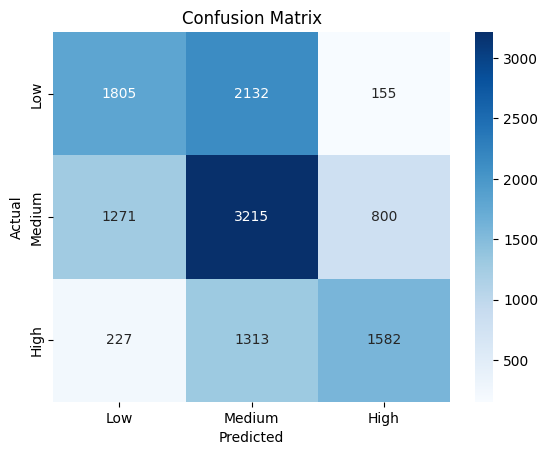

In [29]:
X_train_selected = X_train[["Weekly_GenAI_Hours", "Perceived_AI_Dependency", "Anxiety_Level_During_Exams", "Year_of_Study", "Traditional_Study_Hours", "Pre_Semester_GPA", "Post_Semester_GPA"]]
X_test_selected = X_test[["Weekly_GenAI_Hours", "Perceived_AI_Dependency", "Anxiety_Level_During_Exams", "Year_of_Study", "Traditional_Study_Hours", "Pre_Semester_GPA", "Post_Semester_GPA"]]

model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

conf_matrix = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Conclusion

Feature selection did not improve the model. The metrics achieved might be due to the dataset quality, but also due to the linearity of the model. A consideration to make for the future is to incorporate non-linear models in the predictions, in this case ruling them out because they were outperformed by logistic regression in their base form might have been a premature decision.<br><br>
As for the takeaways from the data, we saw that the two most important features were weekly ai usage and ai dependency, and both showed a strong positive correlation with the burnout risk level. As such, teachers should warn their students about this issue and encourage them to rely more on their own thinking, not just for possibly better performance but also for their own mental well-being.